# Paper figures — interactive driver

Each figure lives as a function in `scripts/analysis/build_paper_figs.py` (`fig1`, `table1`, `figA`, `fig2`, `fig3`). `%autoreload` picks up edits to that module — edit the function, rerun the cell, the re-rendered PNG displays below (PDF + PNG are written to `paper/figs/`). The same module runs headless via `python scripts/analysis/build_paper_figs.py`.

In [1]:
%load_ext autoreload
%autoreload 2

from lora_playground.plotting import paper_figs as bpf
from IPython.display import Image, display

FIGS = bpf.FIGS

## Figure 1 — showcase: loss vs steps, OLMo-2-1B opc r=256

AdamW vs Polar-LoRA (vs iMuon once its grid completes) at each method's best lr; dashed line at AdamW's best final loss; drop-line at the interpolated crossing; tail inset with final losses.

── fig1: Llama-3.2-1B / OpenMathInstruct-2 / r=256  target 0.3823  crossing step 5531  speedup x1.63  arms: ['AdamW', 'Polar-LoRA', 'iMuon']


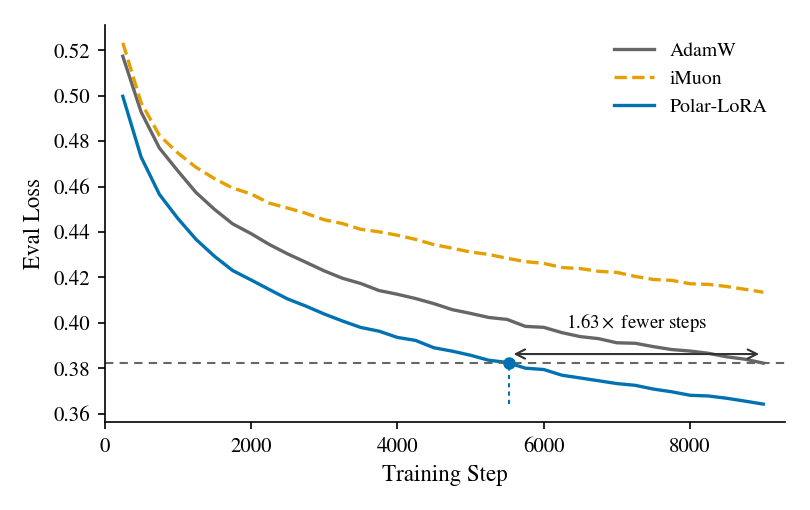

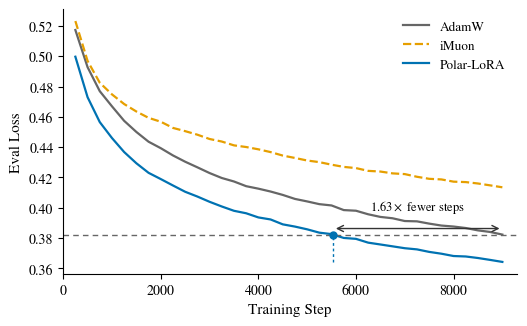

In [2]:
bpf.fig1()
display(Image(str(FIGS / 'fig1_hero.png')))

## Table 1 — per-cell speedup-to-AdamW (LaTeX include)

In [3]:
bpf.table1()
print((FIGS / 'tab1_speedup.tex').read_text())

── table1 rows ──


  Qwen2.5-1.5B / Aya-Bengali / r=256         x1.73 / x1.39
  Llama-3.2-1B / OpenMathInstruct-2 / r=256  x1.63 / x1.40
  OLMo-2-1B / opc-sft-stage2 / r=256         x1.61 / x1.26
  Llama-3.2-1B / opc-sft-stage2 / r=256      x1.55 / x1.24
  Llama-3.2-1B / OpenMathInstruct-2 / r=64   x1.54 / x1.25
  Llama-3.2-1B / OpenMathInstruct-2 / r=128  x1.52 / x1.28
  Llama-3.2-1B / OpenMathInstruct-2 / r=32   x1.48 / x1.23
  Qwen2.5-1.5B / opc-sft-stage2 / r=256      x1.30 / x1.08
  Meta-Llama-3-8B / opc-sft-stage2 / r=256   x1.20 / x1.09
\begin{tabular}{l r r r r r}
\toprule
 & \multicolumn{2}{c}{AdamW} & \multicolumn{3}{c}{\methodname} \\
\cmidrule(lr){2-3}\cmidrule(lr){4-6}
model / dataset / rank & lr & final & lr & speedup & speedup (lr-avg) \\
\midrule
Qwen2.5-1.5B / Aya-Bengali / r=256 & 0.0001 & 0.4979 & 0.03 & 1.73$\times$ & 1.39$\times$ \\
Llama-3.2-1B / OpenMathInstruct-2 / r=256 & 0.0001 & 0.3823 & 0.01 & 1.63$\times$ & 1.40$\times$ \\
OLMo-2-1B / opc-sft-stage2 / r=256 & 0.0001 & 0.7524 

## Appendix figure — tail-zoom grid, one panel per cell

Crossing fraction of the horizon printed at each cell's drop-line.

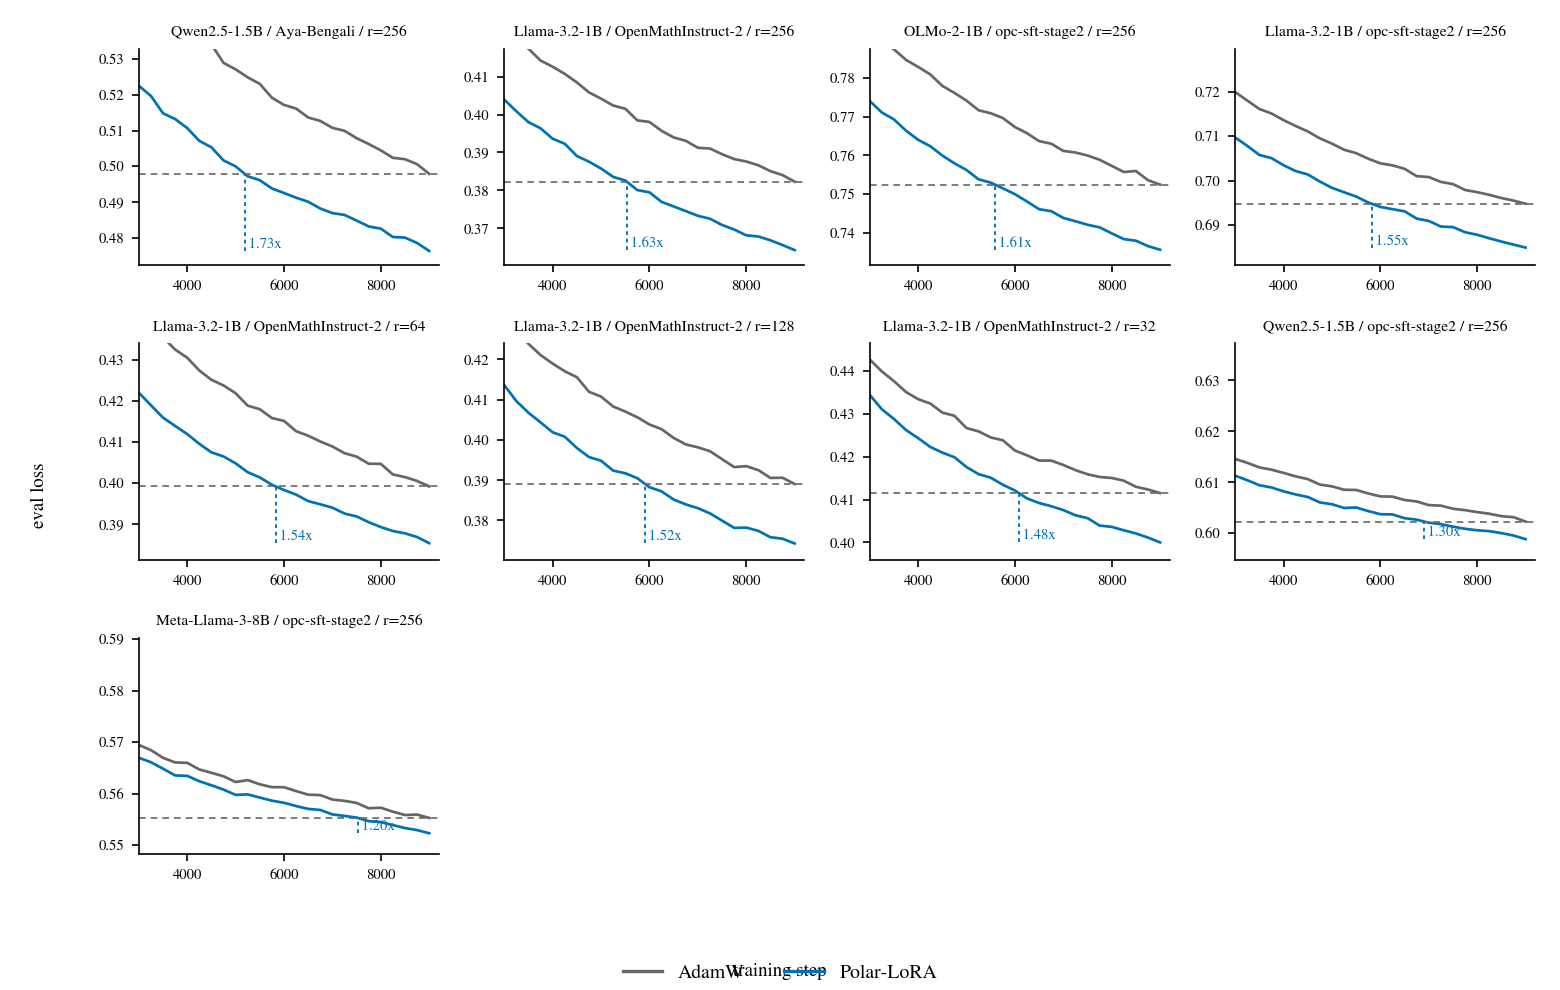

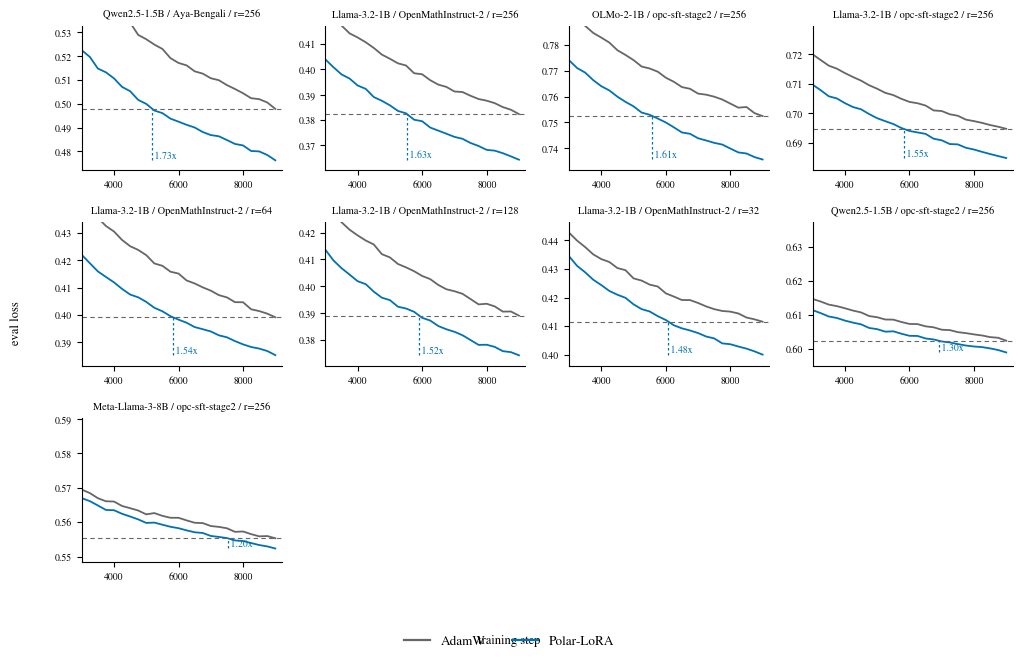

In [4]:
bpf.figA()
display(Image(str(FIGS / 'figA_tailzoom.png')))

## Figure 2 — leave-one-out basins, Llama-3.2-1B openmath r=256

Final loss vs lr for Polar-LoRA / w/o curvature control / w/o magnitude control; ring = each arm's best lr; gray band = sigma_ref above the best final.

── fig2 ablation (openmath r256, sigma=0.0017) ──
  Polar-LoRA               best_lr 0.01  final 0.3643
  w/o curvature control    best_lr 0.001  final 0.3814


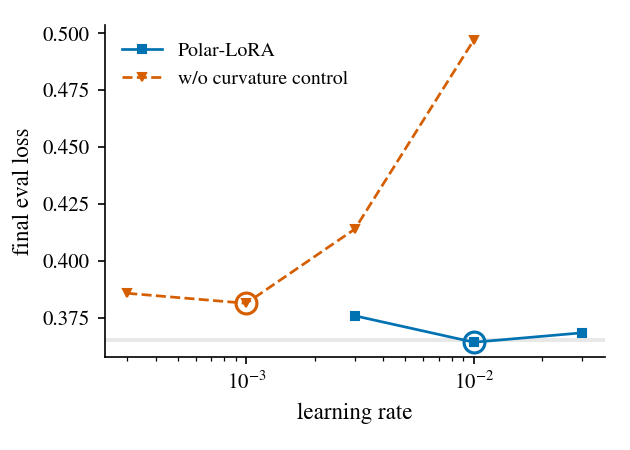

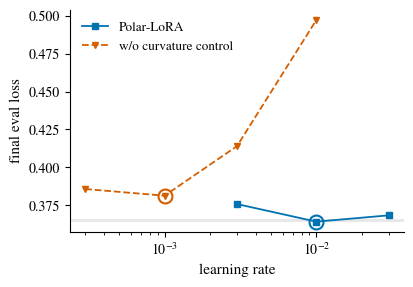

In [5]:
bpf.fig2()
display(Image(str(FIGS / 'fig2_ablation.png')))

## Figure 3 — lr basins across the openmath rank ladder

Shared lr axis across panels; per-panel y zoom; diverged points exit the frame top.

── fig3 lr transfer (openmath r>=32 ladder) ──


  r32 Polar-LoRA   best_lr 0.01  final 0.4000
  r32 AdamW        best_lr 0.0003  final 0.4115


  r64 Polar-LoRA   best_lr 0.01  final 0.3853
  r64 AdamW        best_lr 0.0001  final 0.3991


  r128 Polar-LoRA   best_lr 0.01  final 0.3743
  r128 AdamW        best_lr 0.0001  final 0.3890


  r256 Polar-LoRA   best_lr 0.01  final 0.3643
  r256 AdamW        best_lr 0.0001  final 0.3823


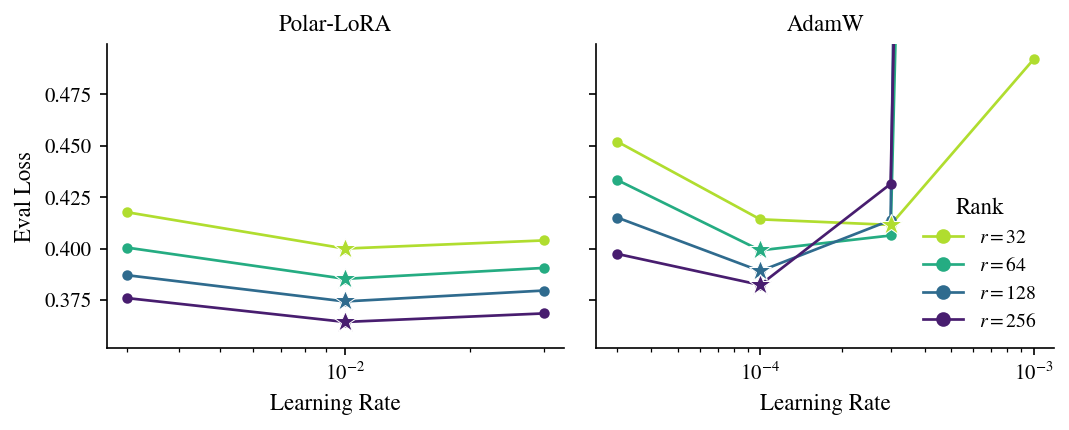

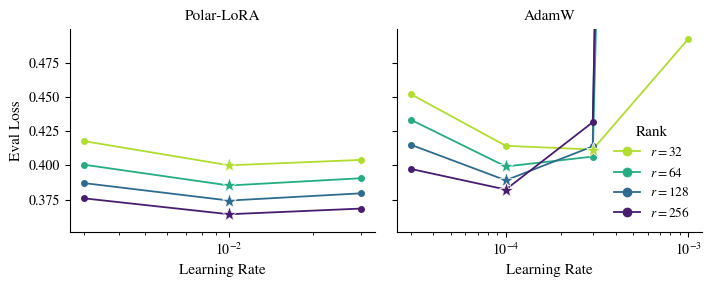

In [6]:
bpf.fig3()
display(Image(str(FIGS / 'fig3_lr_transfer.png')))

## Figure — gauge balance (Llama-3.2-1B openmath r256)

Per-pair (112 LoRA pairs / all layers) over training. **(A)** radius gauge coordinate $\sigma_{max}(A)/\sigma_{max}(B)$ — ours self-balances toward 1. **(B)** BaLoRA balance residual $\|AA^\top{-}BB^\top\|_F/\max$ — neither arm reaches the manifold. Populates when `gauge_kldiag_r256_bw` / `gauge_loramuon_r256_bw` finish.

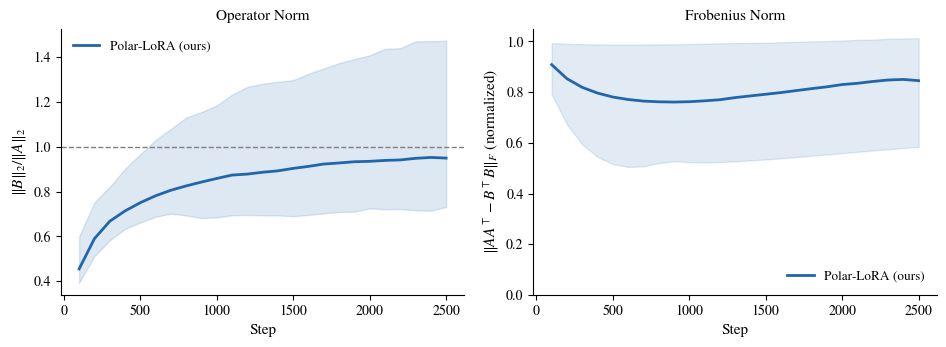

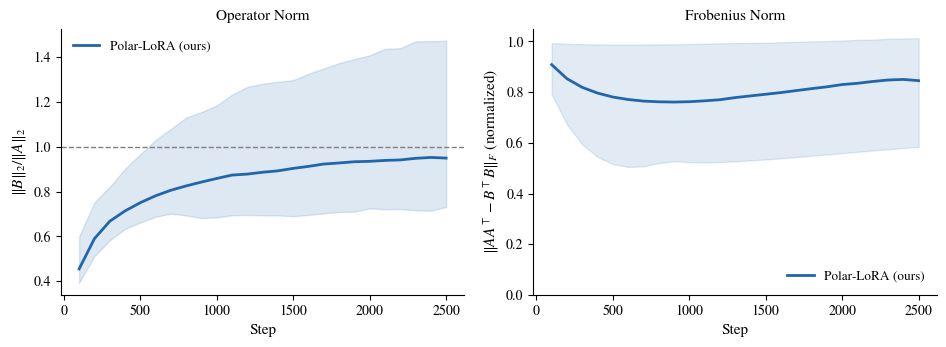

In [7]:
bpf.fig_gauge()